In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv('/content/alzheimers_disease_data.csv')

### Initial Data Inspection

In [4]:
df.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [5]:
df.shape

(2149, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [7]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.nunique()

,0
PatientID,2149
Age,31
Gender,2
Ethnicity,4
EducationLevel,4
BMI,2149
Smoking,2
AlcoholConsumption,2149
PhysicalActivity,2149
DietQuality,2149


In [9]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [10]:
sum(df.duplicated())

0

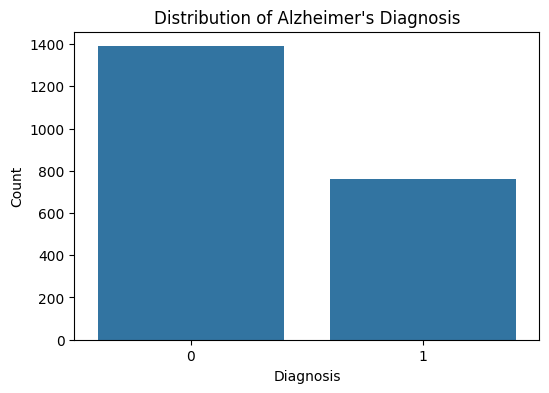

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Diagnosis', data=df)
plt.title("Distribution of Alzheimer's Diagnosis")
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [12]:
df.drop(['PatientID', 'DoctorInCharge'], axis=1, inplace=True)
len(df.columns)

33

In [14]:
numerical_columns = [col for col in df.columns if  df[col].nunique() > 10]

categorical_columns =  df.columns.difference(numerical_columns).difference(['Diagnosis']).to_list()

print("Numerical Columns:", numerical_columns)
print("Categorical Columns:", categorical_columns)

Numerical Columns: ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Categorical Columns: ['BehavioralProblems', 'CardiovascularDisease', 'Confusion', 'Depression', 'Diabetes', 'DifficultyCompletingTasks', 'Disorientation', 'EducationLevel', 'Ethnicity', 'FamilyHistoryAlzheimers', 'Forgetfulness', 'Gender', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'PersonalityChanges', 'Smoking']


### Exploratory Data Analysis

#### Univariate Analysis

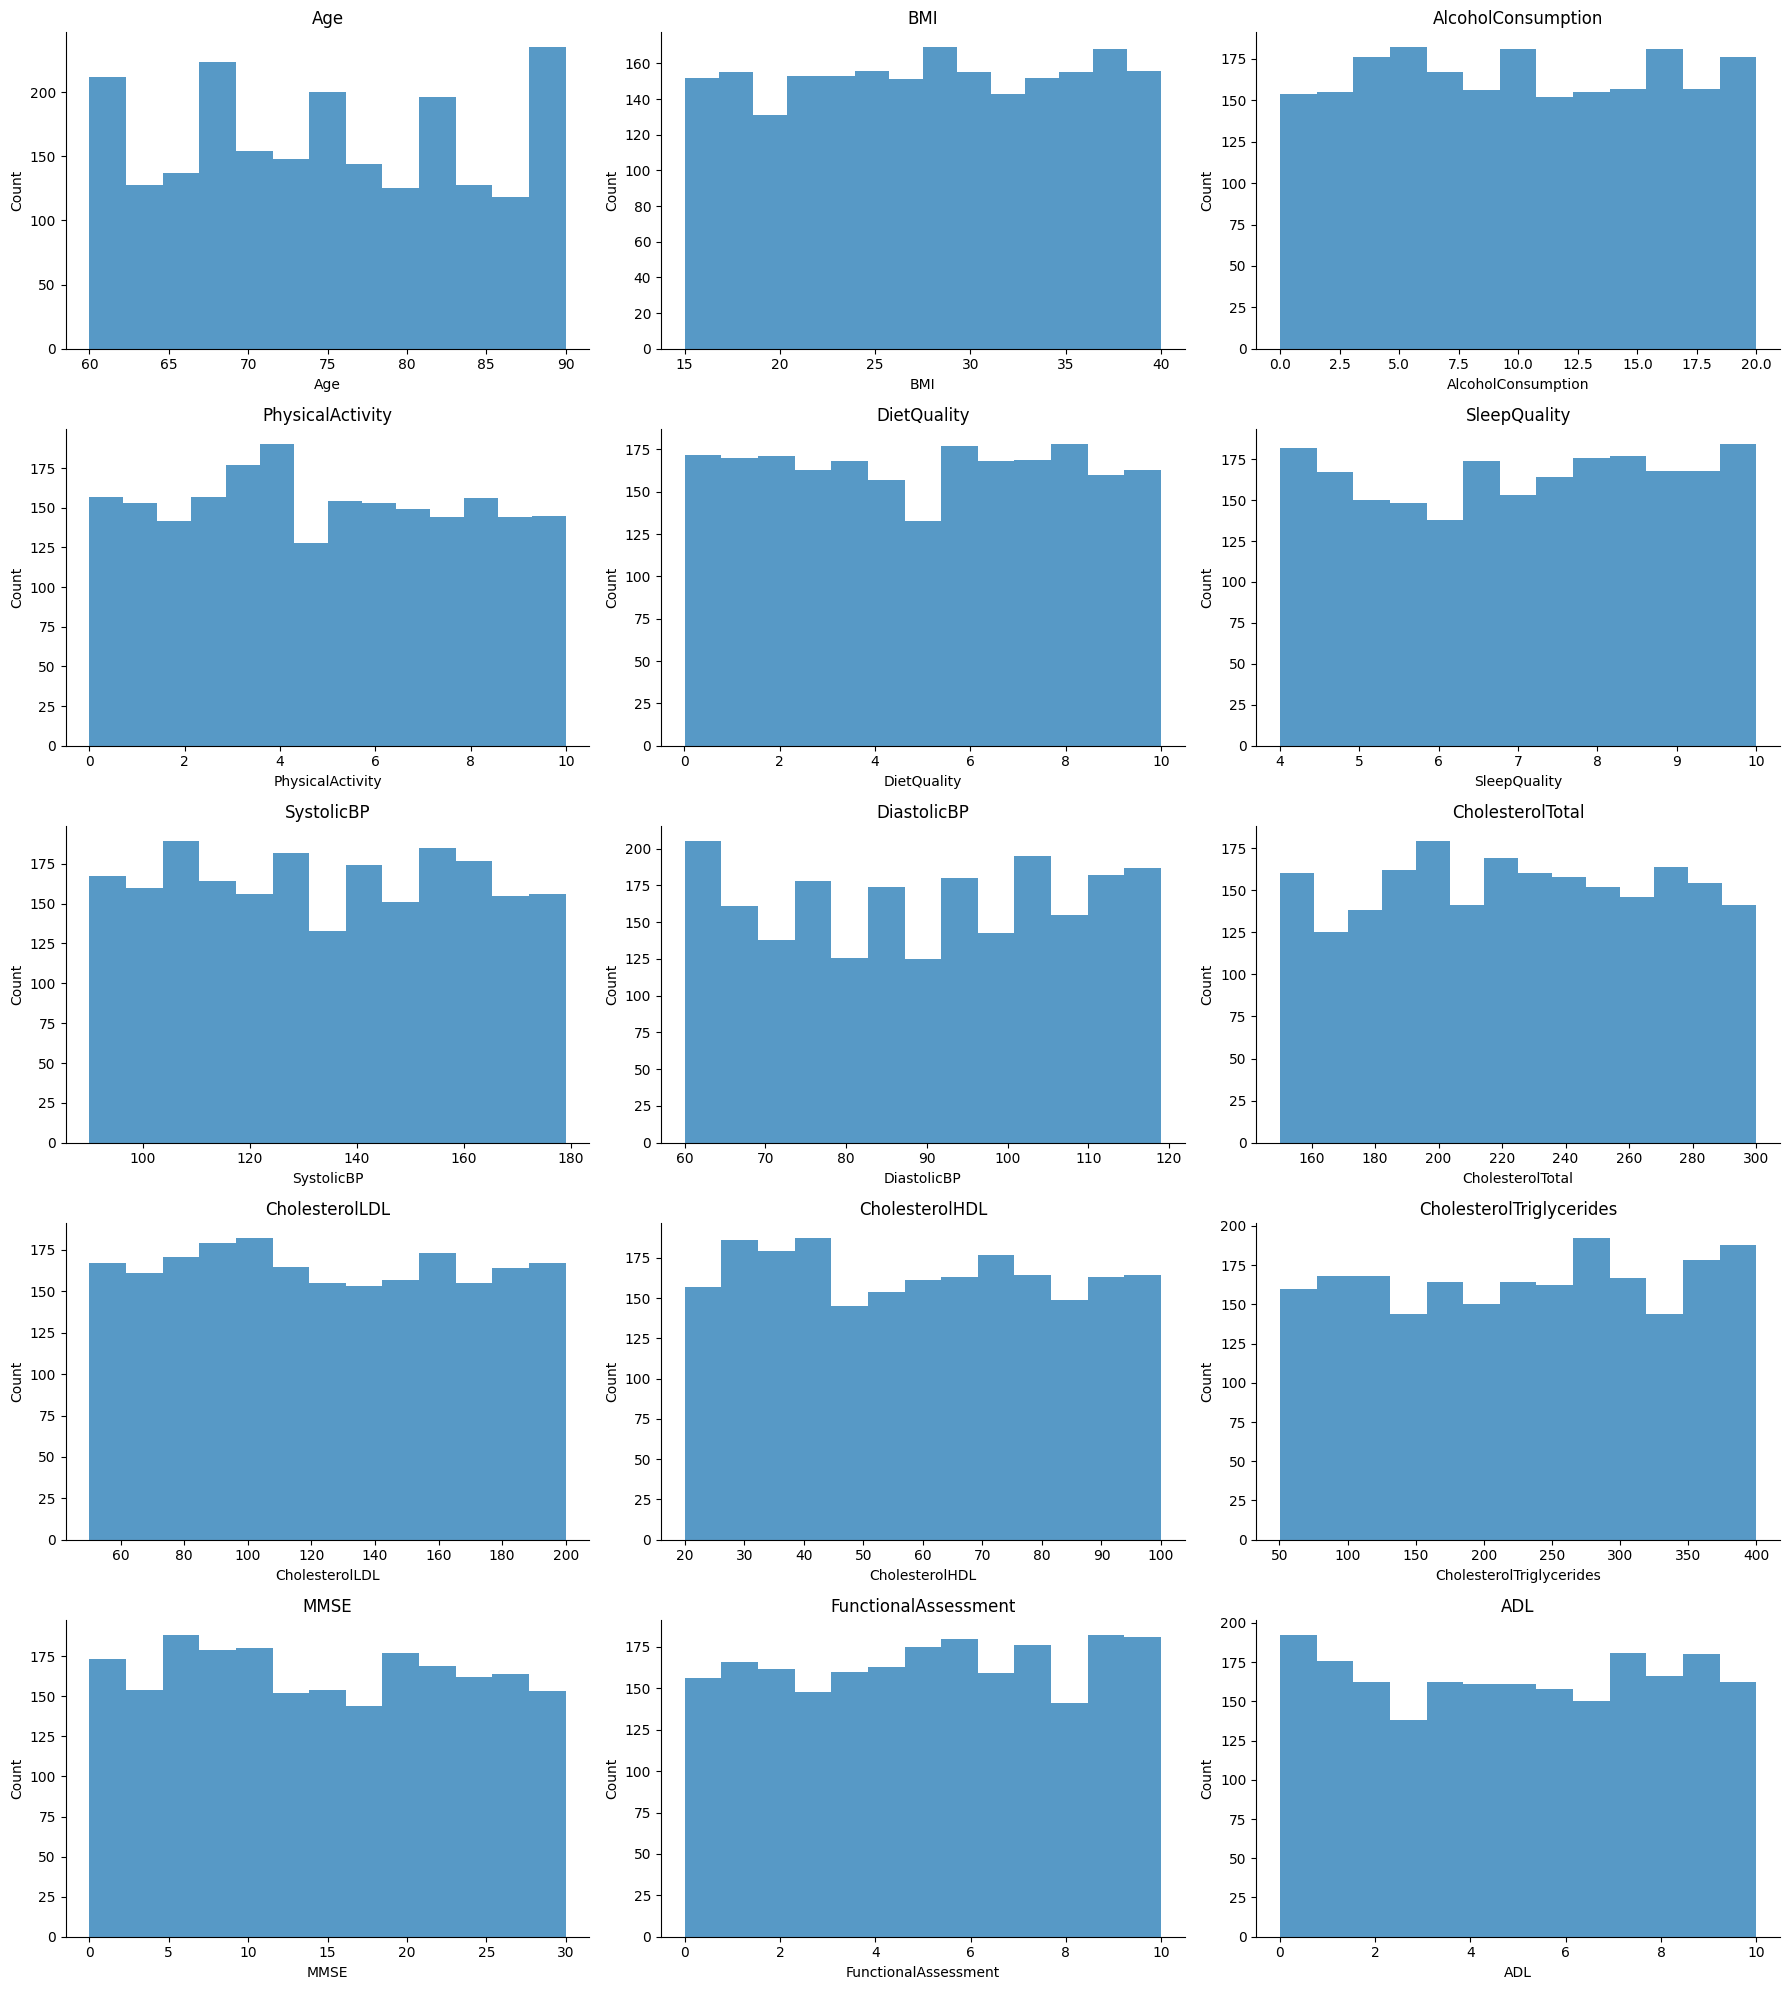

In [15]:
num_features = len(numerical_columns)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, column in enumerate(numerical_columns):
    plt.subplot(num_rows, num_cols, i + 1)

    sns.histplot(df[column], color="#1f77b4", edgecolor=None)
    plt.title(column)

    sns.despine()

plt.tight_layout()
plt.show()

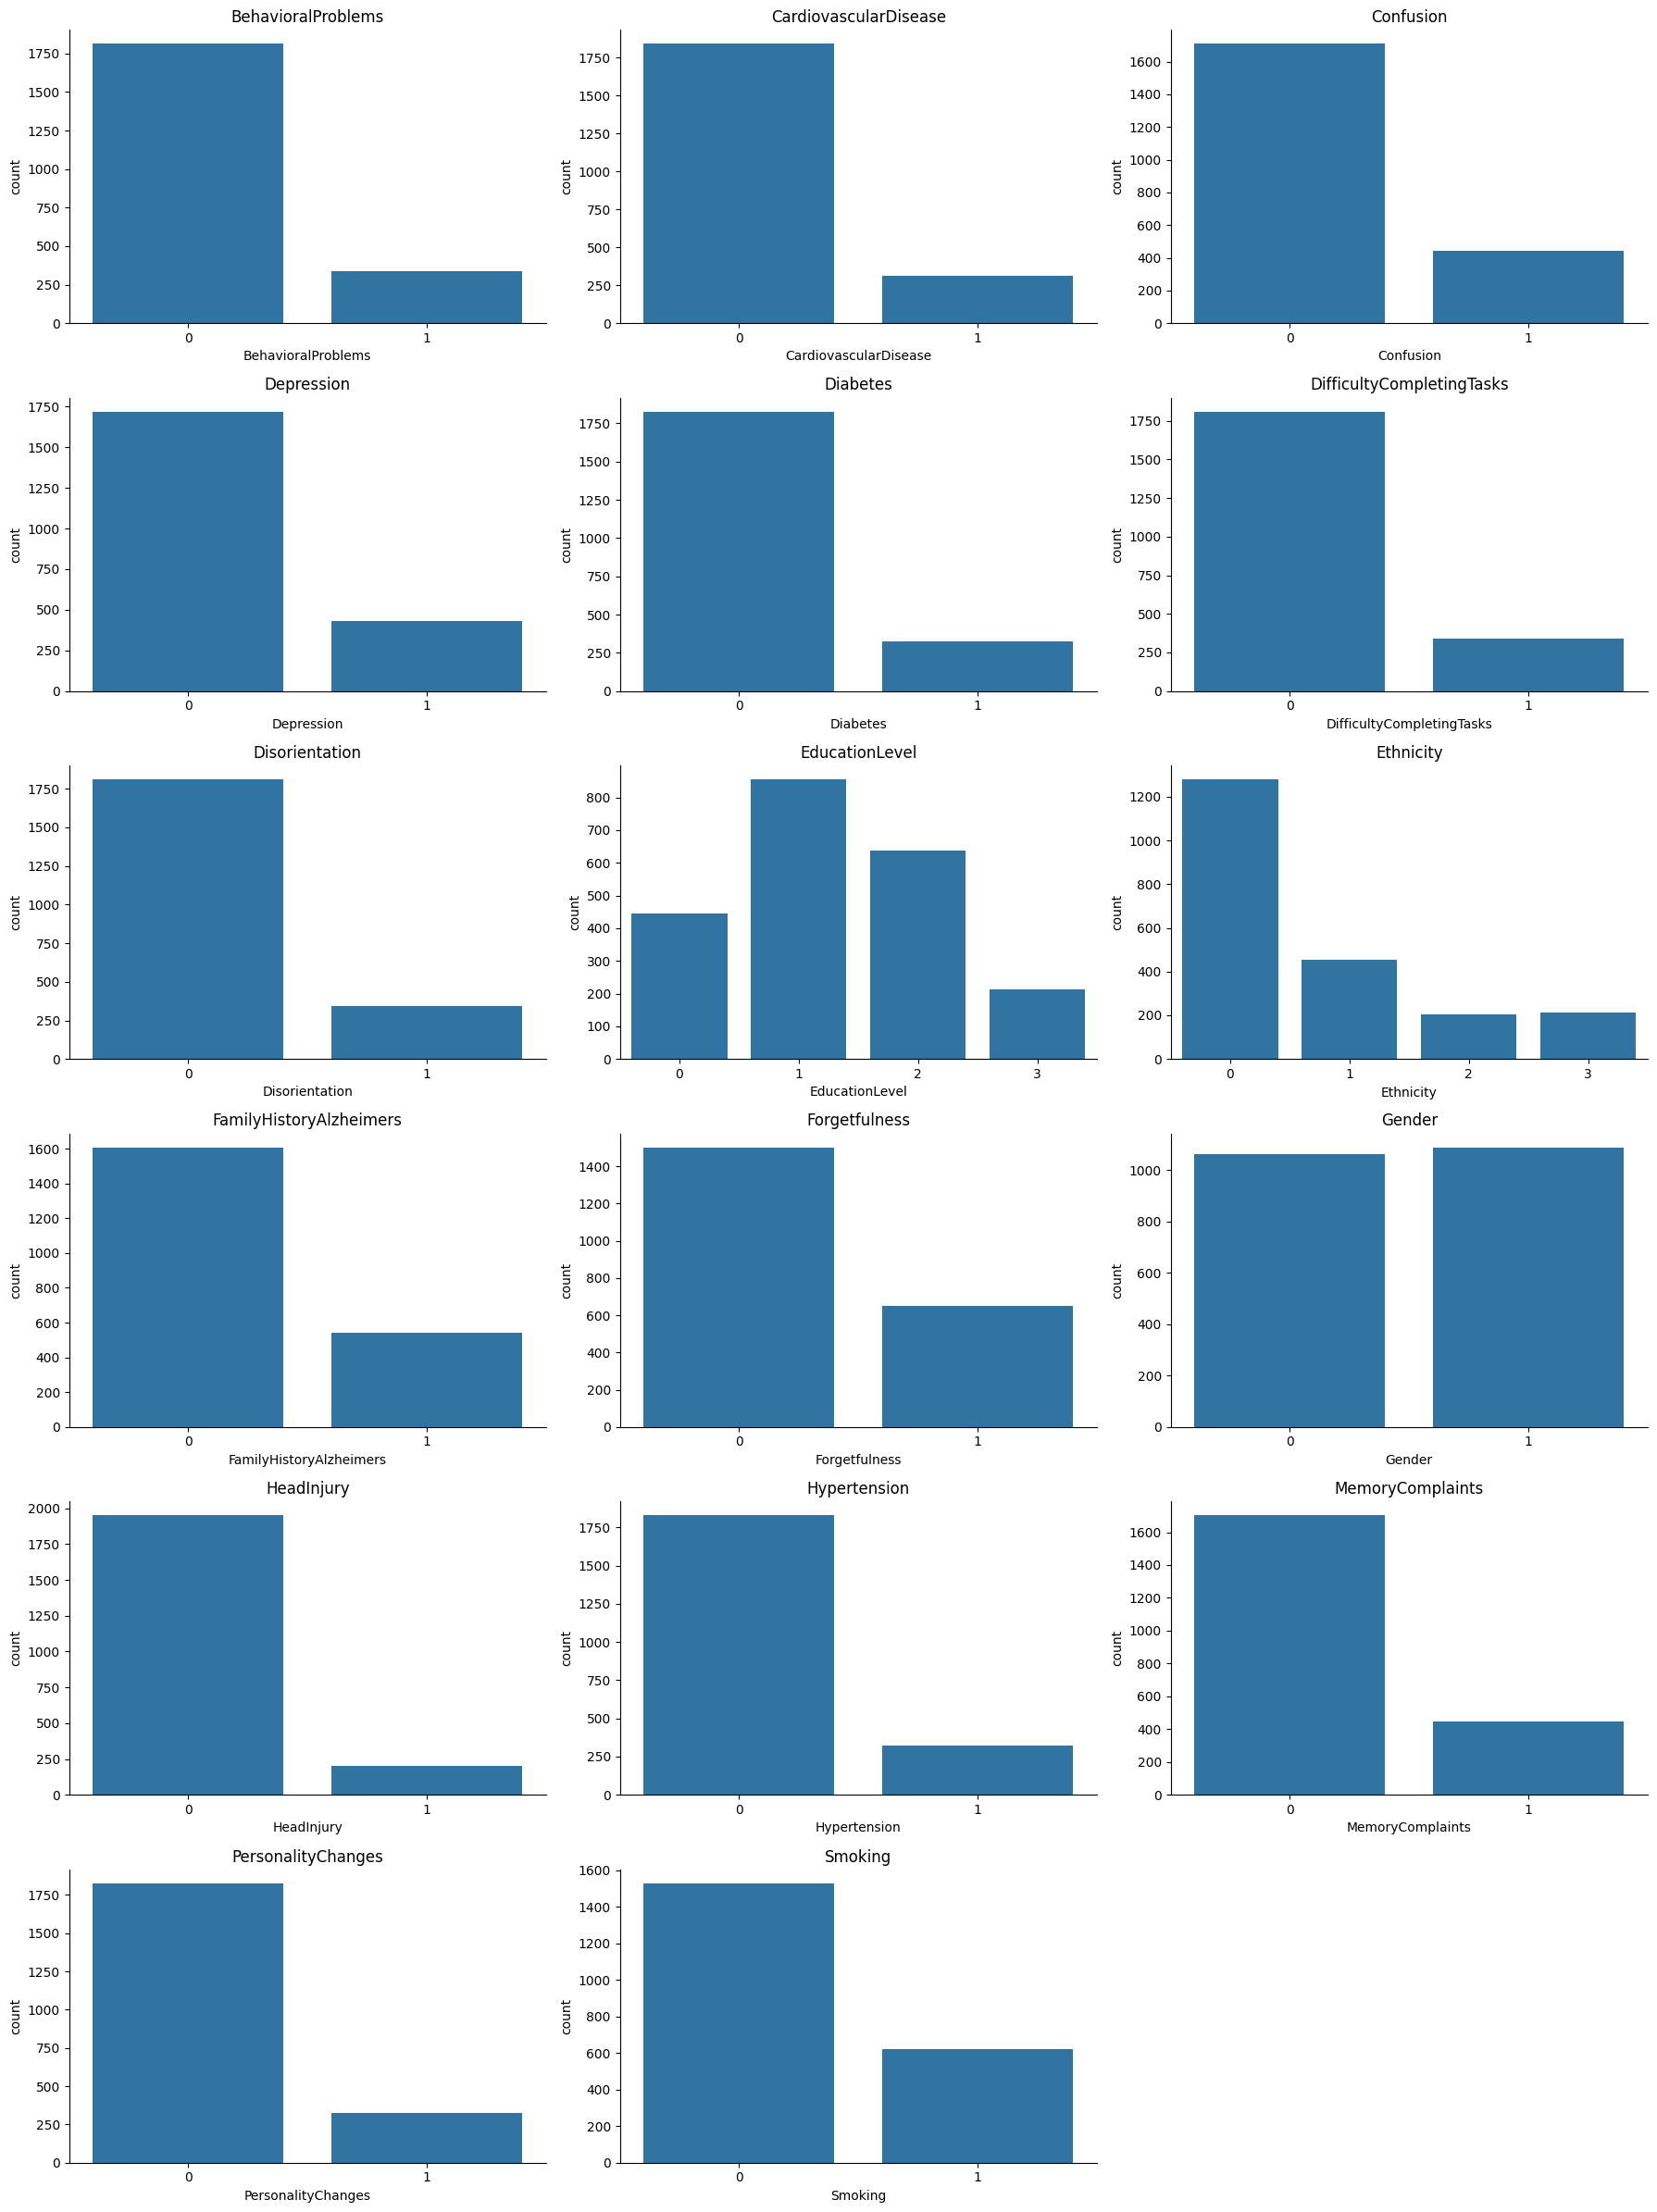

In [16]:
num_features = len(categorical_columns)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, column in enumerate(categorical_columns):
    plt.subplot(num_rows, num_cols, i + 1)

    sns.countplot(x=column, data=df, color="#1f77b4")
    plt.title(column)

    sns.despine()

plt.tight_layout()
plt.show()

#### Bivariate analysis

In [17]:
target = "Diagnosis"

##### Numerical vs Target

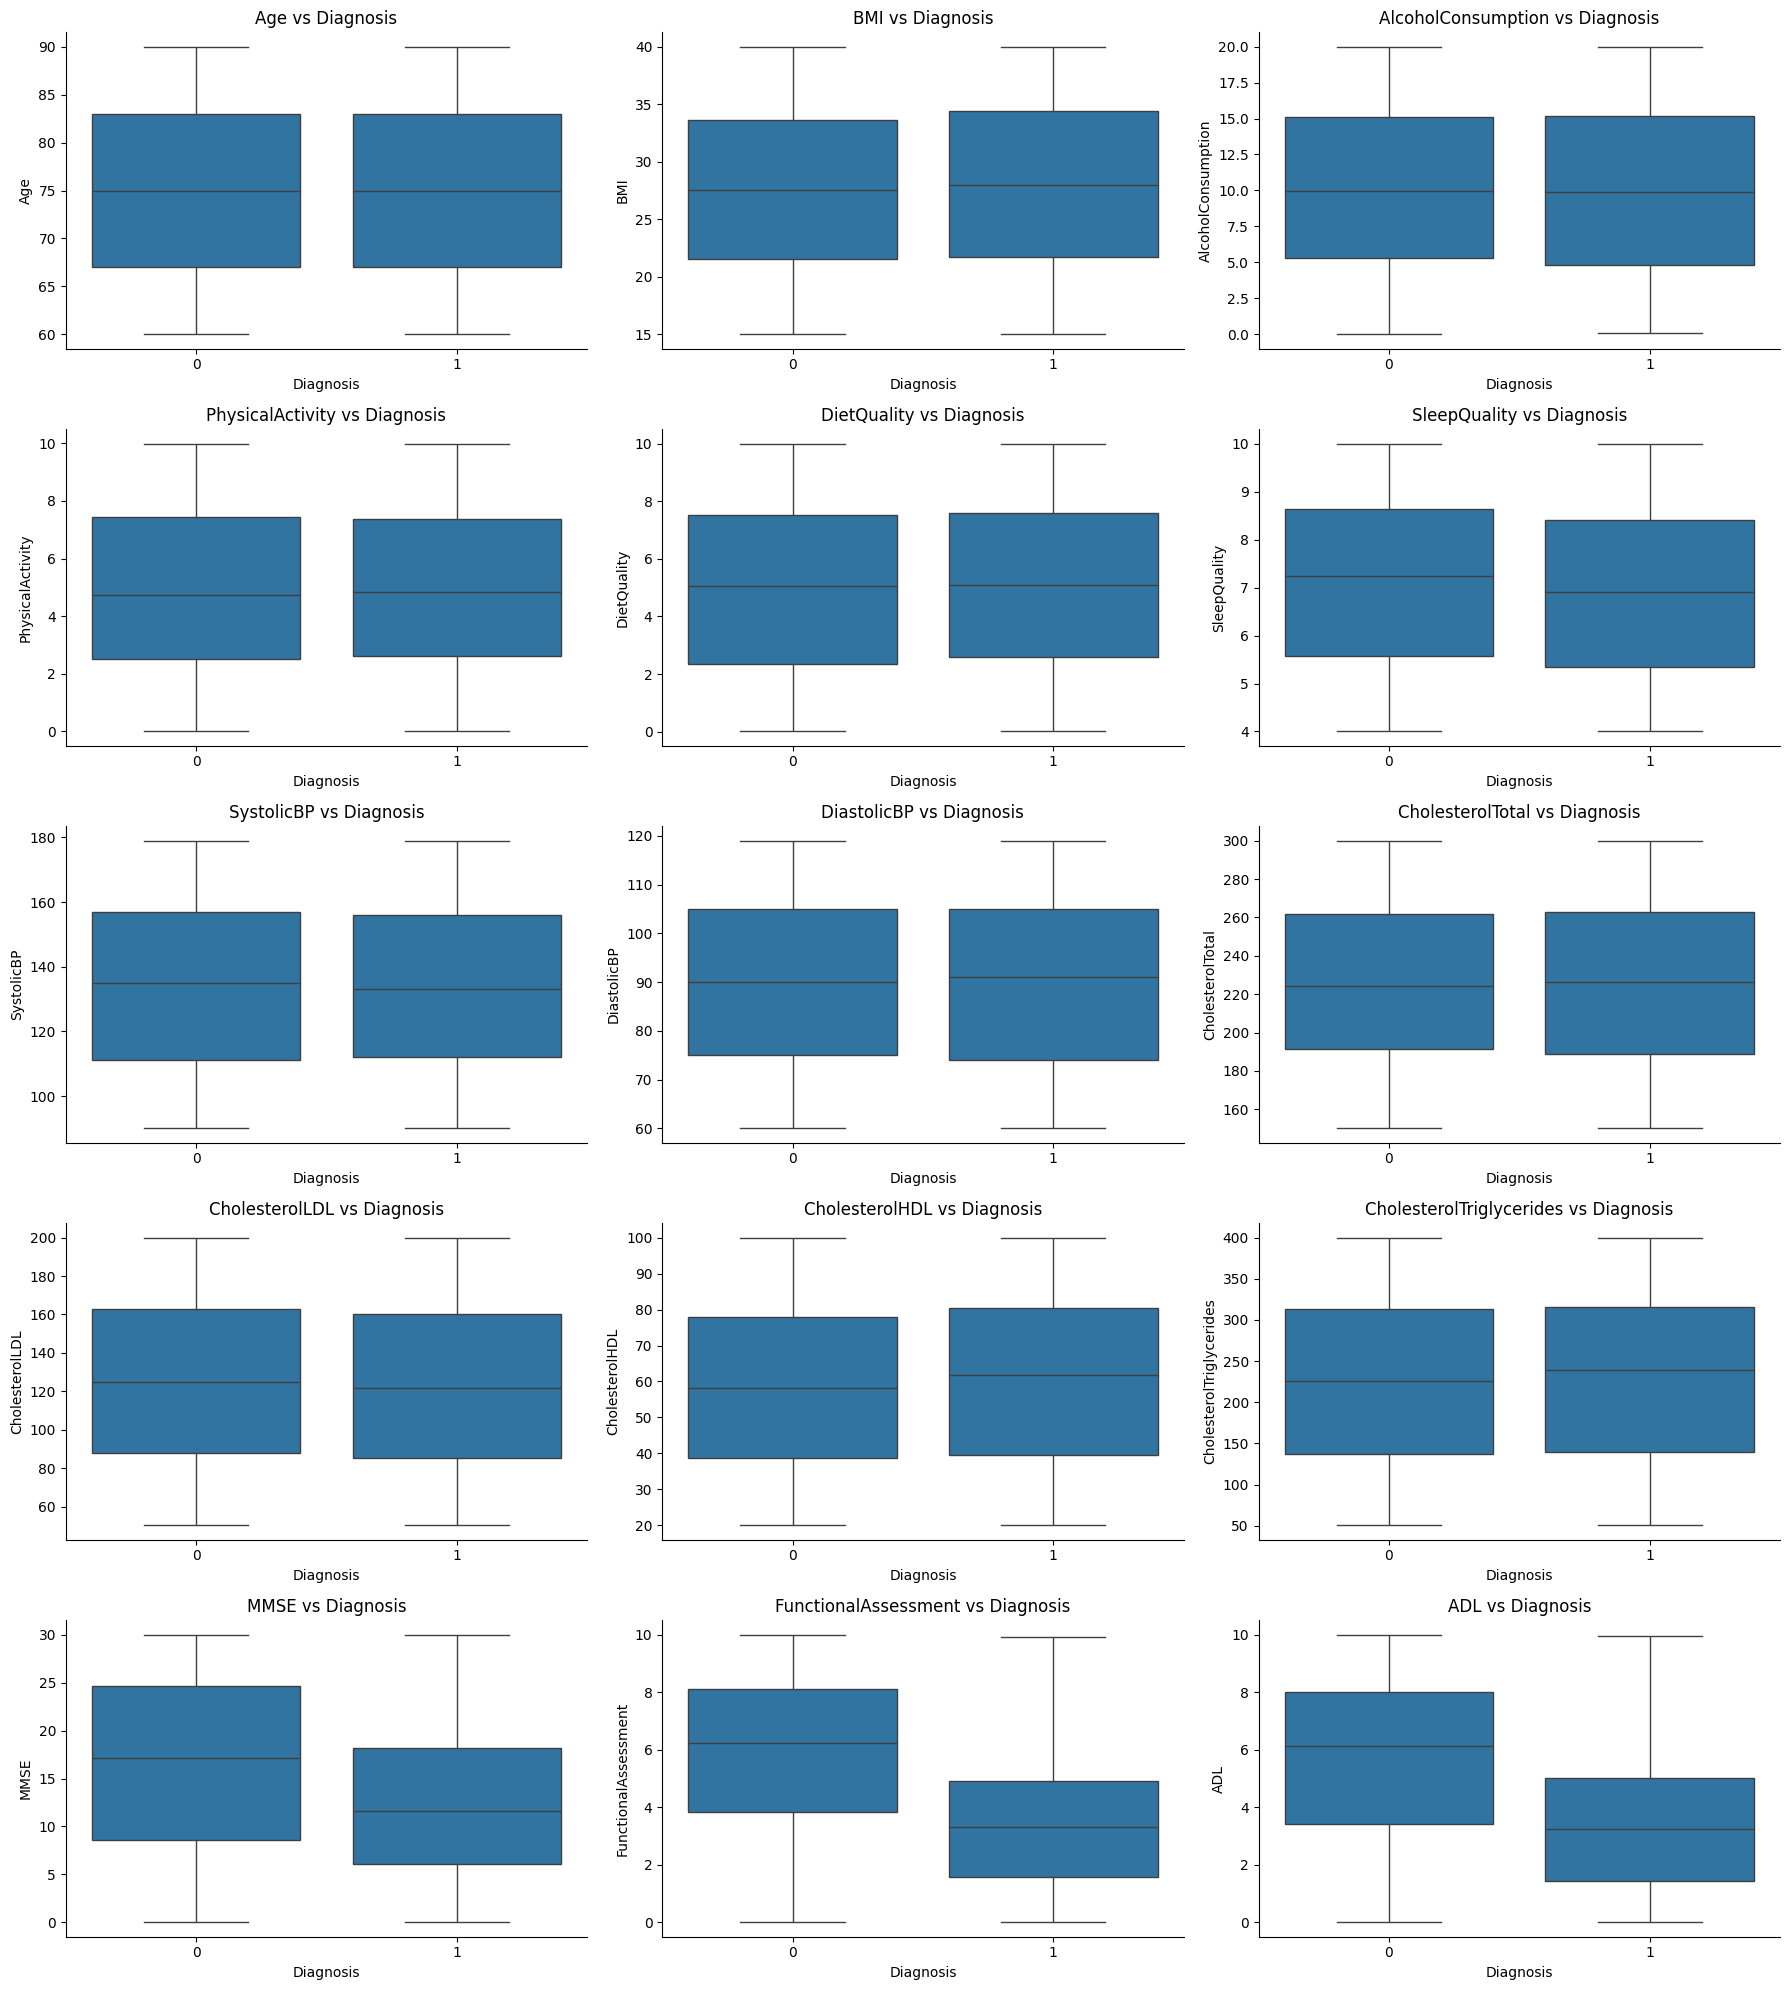

In [18]:
num_features = len(numerical_columns)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, column in enumerate(numerical_columns):
    plt.subplot(num_rows, num_cols, i + 1)

    sns.boxplot(x=target, y=column, data=df, color="#1f77b4")
    plt.title(f"{column} vs {target}")

    sns.despine()

plt.tight_layout()
plt.show()

##### Categorical vs Target

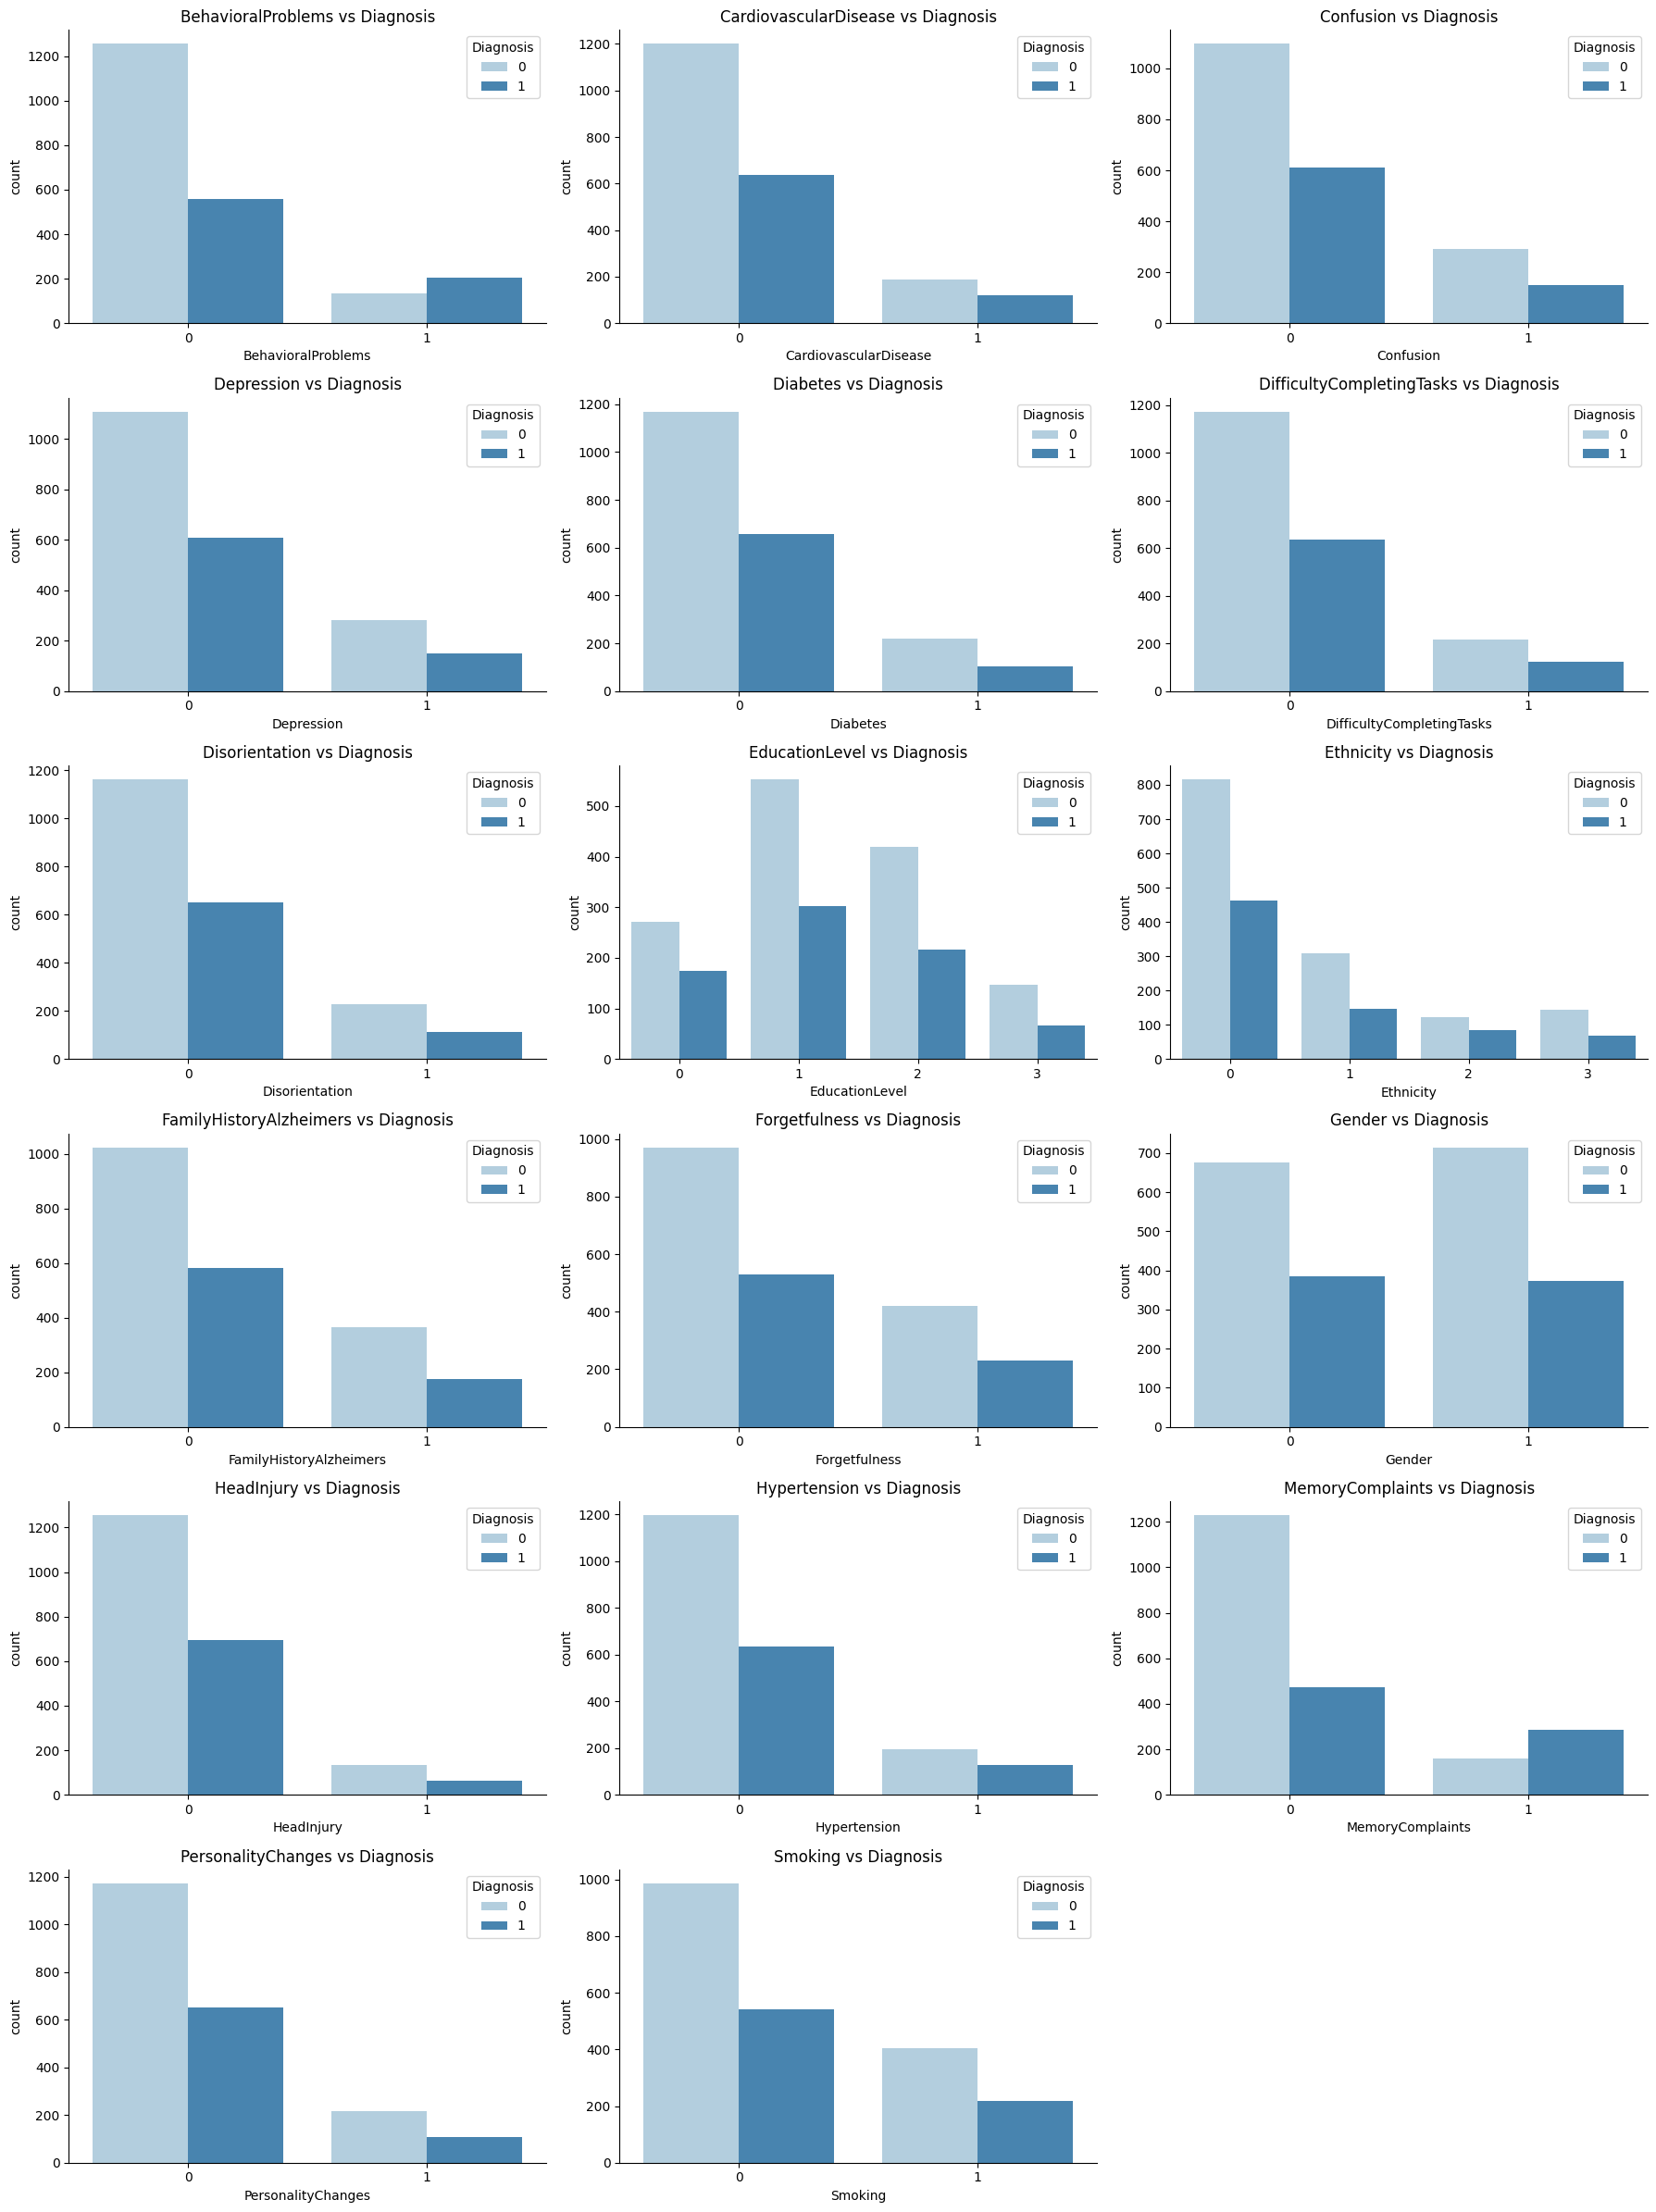

In [19]:
num_features = len(categorical_columns)
num_cols = 3
num_rows = (num_features + num_cols - 1) // num_cols

plt.figure(figsize=(num_cols * 6, num_rows * 4))

for i, column in enumerate(categorical_columns):
    plt.subplot(num_rows, num_cols, i + 1)

    sns.countplot(x=column, hue=target, data=df, palette="Blues")
    plt.title(f"{column} vs {target}")

    sns.despine()

plt.tight_layout()
plt.show()

#### Multi variate analysis - Correlation Heatmap

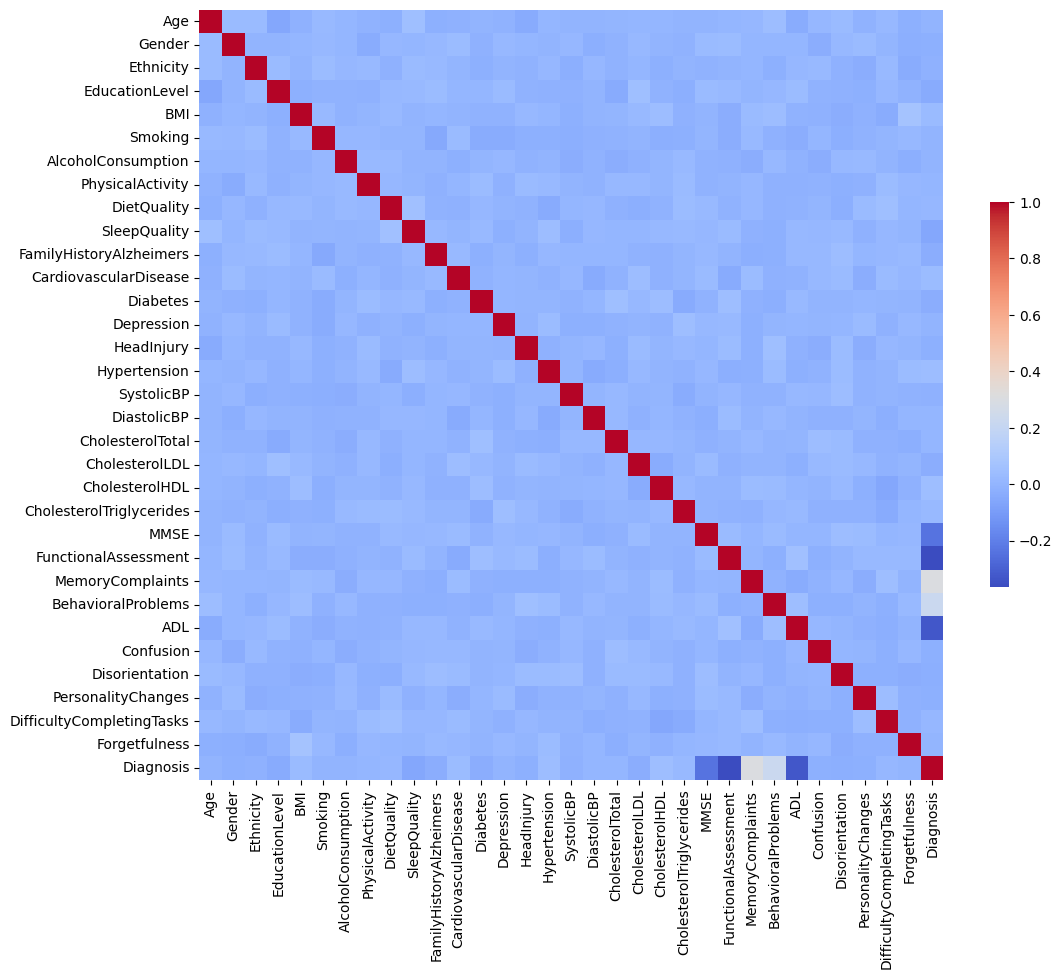

In [ ]:
#heatmap

plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(),cmap="coolwarm", cbar_kws={"shrink": .5})

plt.show()

### Feature Engineering

In [20]:
df['LDL'] = pd.to_numeric(df['CholesterolLDL'], errors='coerce')
df['HDL'] = pd.to_numeric(df['CholesterolHDL'], errors='coerce')

df['HDL'] = df['HDL'].replace(0, 0.0001)
df['Cholesterol_Ratio'] = df['LDL'] / df['HDL']

df.drop(columns=['LDL', 'HDL'], inplace=True)

def categorize_bmi(bmi):
    if pd.isnull(bmi):
        return np.nan
    elif bmi < 18.5:
        return 0 # 0  # Underweight
    elif 18.5 <= bmi < 25:
        return 1 # 1  # Normal
    elif 25 <= bmi < 30:
        return 2 # 2  # Overweight
    else:
        return 3 # 3  # Obese

df['BMI_Category'] = df['BMI'].apply(categorize_bmi)

df['Age_CholesterolRatio'] = df['Age'] * df['Cholesterol_Ratio']

df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']

In [21]:
from sklearn.preprocessing import OneHotEncoder

ethnicity_map = {
    0: 'Caucasian',
    1: 'African_American',
    2: 'Asian',
    3: 'Other'
}

df['Ethnicity'] = df['Ethnicity'].map(ethnicity_map)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
ohe_transform = ohe.fit_transform(df[['Ethnicity']])

df = pd.concat([df, ohe_transform], axis=1).drop(columns=['Ethnicity'])

In [22]:
education_map = {
    0: 'None',
    1: 'High_School',
    2: 'Bachelors',
    3: 'Higher'
}

df['EducationLevel'] = df['EducationLevel'].map(education_map)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
ohe_transform = ohe.fit_transform(df[['EducationLevel']])

df = pd.concat([df, ohe_transform], axis=1).drop(columns=['EducationLevel'])

In [23]:
bmi_category_map = {
    0: 'Underweight',
    1: 'Normal',
    2: 'Overweight',
    3: 'Obese'
}

df['BMI_Category'] = df['BMI_Category'].map(bmi_category_map)

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform="pandas")
ohe_transform = ohe.fit_transform(df[['BMI_Category']])

df = pd.concat([df, ohe_transform], axis=1).drop(columns=['BMI_Category'])

In [24]:
df.to_csv("/content/Processed_Alzheimers_data.csv", index=False)

In [25]:
for column in df.columns:
    unique_values = df[column].unique()
    print(f"Unique values in column '{column}' of type {df[column].dtype}:")
    print(unique_values)
    print()

Unique values in column 'Age' of type int64:
[73 89 74 86 68 75 72 87 78 84 64 69 63 65 82 77 71 83 79 67 66 70 85 60
 88 62 81 61 80 90 76]

Unique values in column 'Gender' of type int64:
[0 1]

Unique values in column 'BMI' of type float64:
[22.92774923 26.82768119 17.79588244 ... 15.47647896 15.29991122
 33.28973831]

Unique values in column 'Smoking' of type int64:
[0 1]

Unique values in column 'AlcoholConsumption' of type float64:
[13.29721773  4.54252382 19.55508453 ...  4.59467018  8.67450518
  7.89070315]

Unique values in column 'PhysicalActivity' of type float64:
[6.32711247 7.61988454 7.84498779 ... 9.88600229 6.35428175 6.57099338]

Unique values in column 'DietQuality' of type float64:
[1.34721431 0.51876714 1.82633466 ... 8.12002455 1.26342749 7.94140388]

Unique values in column 'SleepQuality' of type float64:
[9.02567867 7.15129274 9.67357416 ... 5.76946355 8.32287396 9.87871052]

Unique values in column 'FamilyHistoryAlzheimers' of type int64:
[0 1]

Unique values in

### Feature Selection

In [26]:
X = df.drop(columns = ['Diagnosis'])
y = df['Diagnosis']
print(X.shape)
print(y.shape)

(2149, 45)
(2149,)


In [27]:
X.columns

Index(['Age', 'Gender', 'BMI', 'Smoking', 'AlcoholConsumption',
       'PhysicalActivity', 'DietQuality', 'SleepQuality',
       'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes',
       'Depression', 'HeadInjury', 'Hypertension', 'SystolicBP', 'DiastolicBP',
       'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL',
       'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment',
       'MemoryComplaints', 'BehavioralProblems', 'ADL', 'Confusion',
       'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks',
       'Forgetfulness', 'Cholesterol_Ratio', 'Age_CholesterolRatio',
       'PulsePressure', 'Ethnicity_African_American', 'Ethnicity_Asian',
       'Ethnicity_Caucasian', 'Ethnicity_Other', 'EducationLevel_Bachelors',
       'EducationLevel_High_School', 'EducationLevel_Higher',
       'EducationLevel_None', 'BMI_Category_Normal', 'BMI_Category_Obese',
       'BMI_Category_Overweight', 'BMI_Category_Underweight'],
      dtype='object')

In [28]:
from sklearn.feature_selection import SelectKBest, f_classif, chi2
import pandas as pd
import numpy as np

P_VALUE_THRESHOLD = 0.1

# Numerical/Ordinal features for ANOVA
num_ord_features = ['Age', 'BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL', 'Cholesterol_Ratio', 'Age_CholesterolRatio', 'PulsePressure']
cat_features = ['BMI_Category_Normal', 'BMI_Category_Obese', 'BMI_Category_Overweight', 'BMI_Category_Underweight', 'BehavioralProblems', 'CardiovascularDisease', 'Confusion', 'Depression', 'Diabetes', 'DifficultyCompletingTasks', 'Disorientation', 'EducationLevel_Bachelors', 'EducationLevel_High_School', 'EducationLevel_Higher', 'EducationLevel_None', 'Ethnicity_African_American', 'Ethnicity_Asian', 'Ethnicity_Caucasian', 'Ethnicity_Other', 'FamilyHistoryAlzheimers', 'Forgetfulness', 'Gender', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'PersonalityChanges', 'Smoking']

# --- ANOVA ---
fs_anova = SelectKBest(score_func=f_classif, k='all')
fs_anova.fit(X[num_ord_features], y)

anova_results = pd.DataFrame({
    'Feature': num_ord_features,
    'P-Value': fs_anova.pvalues_,
    'Method': 'ANOVA'
})
anova_results['Score'] = -np.log(anova_results['P-Value'] + 1e-12)

# print("\nANOVA F-test Results:")
# print(anova_results.sort_values(by='P-Value'))

# --- Chi-Square ---
fs_chi2 = SelectKBest(score_func=chi2, k='all')
fs_chi2.fit(X[cat_features], y)

chi2_results = pd.DataFrame({
    'Feature': cat_features,
    'P-Value': fs_chi2.pvalues_,
    'Method': 'Chi-Square'
})
chi2_results['Score'] = -np.log(chi2_results['P-Value'] + 1e-12)

# print("\nChi-Squared Test Results:")
# print(chi2_results.sort_values(by='P-Value'))

# ---- Combine + Ranking ----
combined_ranking = pd.concat([anova_results, chi2_results], ignore_index=True)
combined_ranking = combined_ranking.sort_values(by='Score', ascending=False)

print("\n========== FINAL RANKED FEATURES (Descending Importance) ==========")
print(combined_ranking[['Feature', 'P-Value', 'Score', 'Method']])



========== FINAL RANKED FEATURES (Descending Importance) ==========
                       Feature       P-Value      Score      Method
12                        MMSE  7.537248e-29  27.631021       ANOVA
14                         ADL  1.396884e-56  27.631021       ANOVA
42            MemoryComplaints  1.053099e-36  27.631021  Chi-Square
13        FunctionalAssessment  1.134785e-68  27.631021       ANOVA
22          BehavioralProblems  1.296254e-21  27.631021  Chi-Square
5                 SleepQuality  8.741801e-03   4.739639       ANOVA
15           Cholesterol_Ratio  1.086423e-02   4.522279       ANOVA
16        Age_CholesterolRatio  1.093045e-02   4.516203       ANOVA
10              CholesterolHDL  4.840127e-02   3.028229       ANOVA
34             Ethnicity_Asian  1.042667e-01   2.260803  Chi-Square
32         EducationLevel_None  1.070786e-01   2.234192  Chi-Square
41                Hypertension  1.335468e-01   2.013304  Chi-Square
9               CholesterolLDL  1.383856e-01   

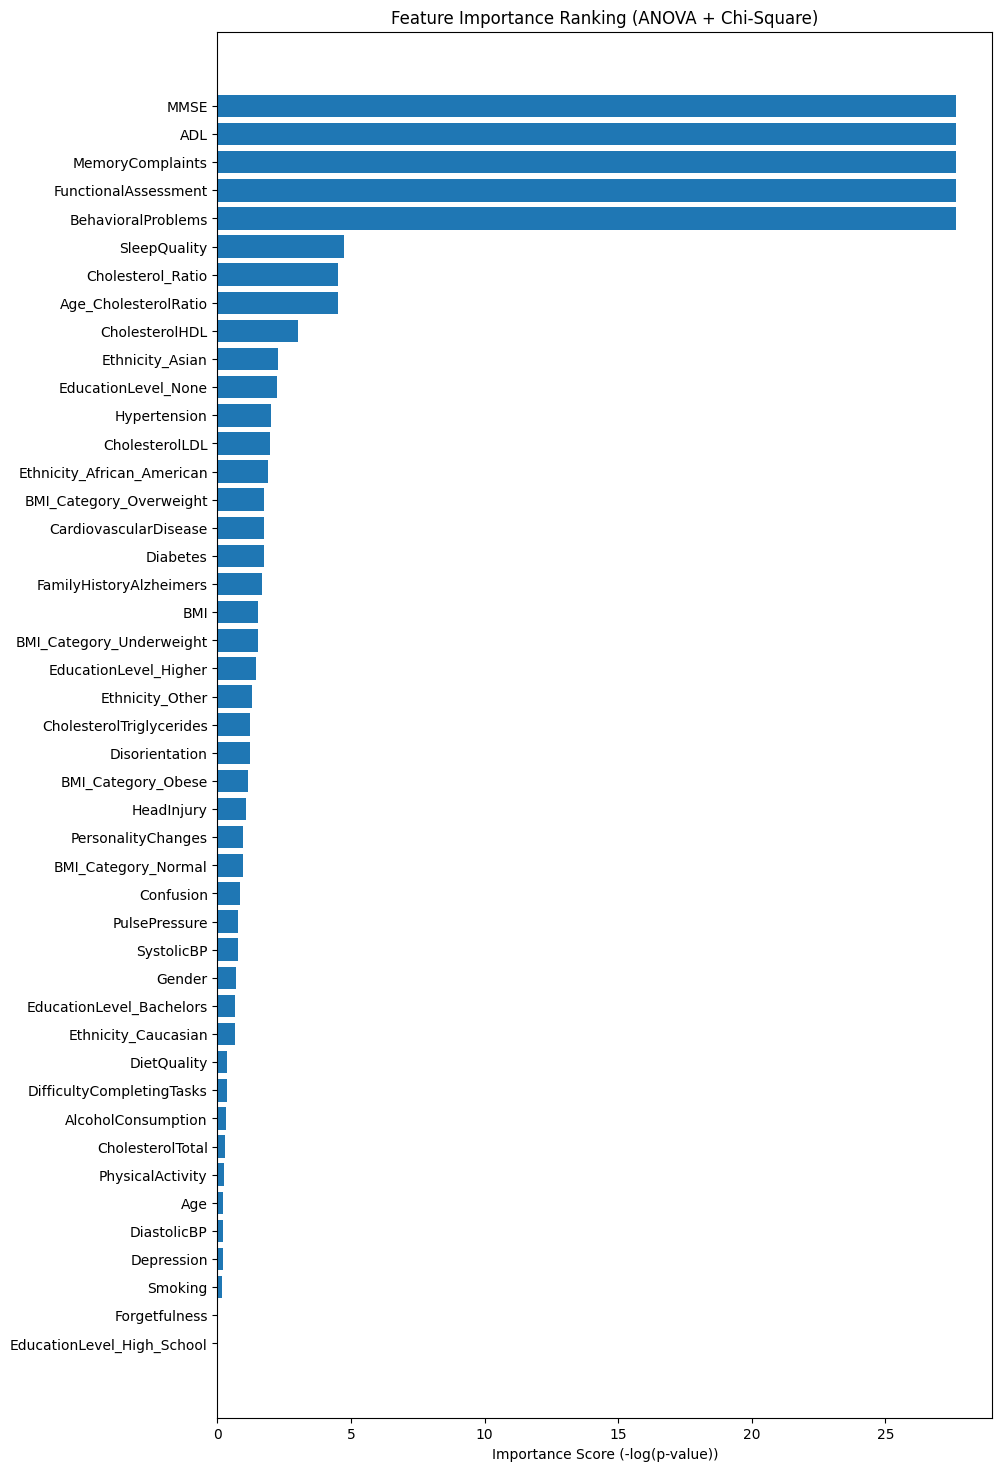

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 18))
plt.barh(combined_ranking['Feature'], combined_ranking['Score'])
plt.xlabel('Importance Score (-log(p-value))')
plt.title('Feature Importance Ranking (ANOVA + Chi-Square)')
plt.gca().invert_yaxis()
plt.show()

In [30]:
SCORE_THRESHOLD = 1.0

selected_features = combined_ranking[
    combined_ranking['Score'] > SCORE_THRESHOLD
]['Feature'].tolist()
selected_features.append('Age')
print(f"Selected Features (Score > {SCORE_THRESHOLD}):")
print(selected_features)
print(f"\nTotal Selected Features: {len(selected_features)}")

Selected Features (Score > 1.0):
['MMSE', 'ADL', 'MemoryComplaints', 'FunctionalAssessment', 'BehavioralProblems', 'SleepQuality', 'Cholesterol_Ratio', 'Age_CholesterolRatio', 'CholesterolHDL', 'Ethnicity_Asian', 'EducationLevel_None', 'Hypertension', 'CholesterolLDL', 'Ethnicity_African_American', 'BMI_Category_Overweight', 'CardiovascularDisease', 'Diabetes', 'FamilyHistoryAlzheimers', 'BMI', 'BMI_Category_Underweight', 'EducationLevel_Higher', 'Ethnicity_Other', 'CholesterolTriglycerides', 'Disorientation', 'BMI_Category_Obese', 'HeadInjury', 'Age']

Total Selected Features: 27


In [31]:
X = df[selected_features]
y = df["Diagnosis"]

In [32]:
from sklearn.ensemble import RandomForestClassifier

print("\n--- 2. Running Embedded Step (Random Forest on Selected Features) ---")

# 2) Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X, y)

# 3) Get RF importances on selected features
rf_importances = rf_model.feature_importances_

# Filter combined_ranking to include only selected_features
filtered_combined_ranking = combined_ranking[combined_ranking['Feature'].isin(selected_features)]

rf_selected_df = pd.DataFrame({
    'Feature': selected_features,
    'RF_Importance': rf_importances,
    'Original_Score': filtered_combined_ranking.set_index('Feature').loc[selected_features]['Score'].values,
    'Method': filtered_combined_ranking.set_index('Feature').loc[selected_features]['Method'].values
}).sort_values(by='RF_Importance', ascending=False)

print("\n===== FINAL RANDOM FOREST IMPORTANCE (on selected features) =====")
print(rf_selected_df)


--- 2. Running Embedded Step (Random Forest on Selected Features) ---

===== FINAL RANDOM FOREST IMPORTANCE (on selected features) =====
                       Feature  RF_Importance  Original_Score      Method
3         FunctionalAssessment       0.209815       27.631021       ANOVA
1                          ADL       0.182404       27.631021       ANOVA
0                         MMSE       0.148768       27.631021       ANOVA
2             MemoryComplaints       0.096101       27.631021  Chi-Square
4           BehavioralProblems       0.061302       27.631021  Chi-Square
22    CholesterolTriglycerides       0.034664        1.225966       ANOVA
5                 SleepQuality       0.033003        4.739639       ANOVA
18                         BMI       0.032190        1.504150       ANOVA
8               CholesterolHDL       0.031768        3.028229       ANOVA
12              CholesterolLDL       0.031428        1.977711       ANOVA
6            Cholesterol_Ratio       0.031016   

In [33]:
import pandas as pd

rf_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

rf_importance

,0
FunctionalAssessment,0.209815
ADL,0.182404
MMSE,0.148768
MemoryComplaints,0.096101
BehavioralProblems,0.061302
CholesterolTriglycerides,0.034664
SleepQuality,0.033003
BMI,0.032190
CholesterolHDL,0.031768
CholesterolLDL,0.031428


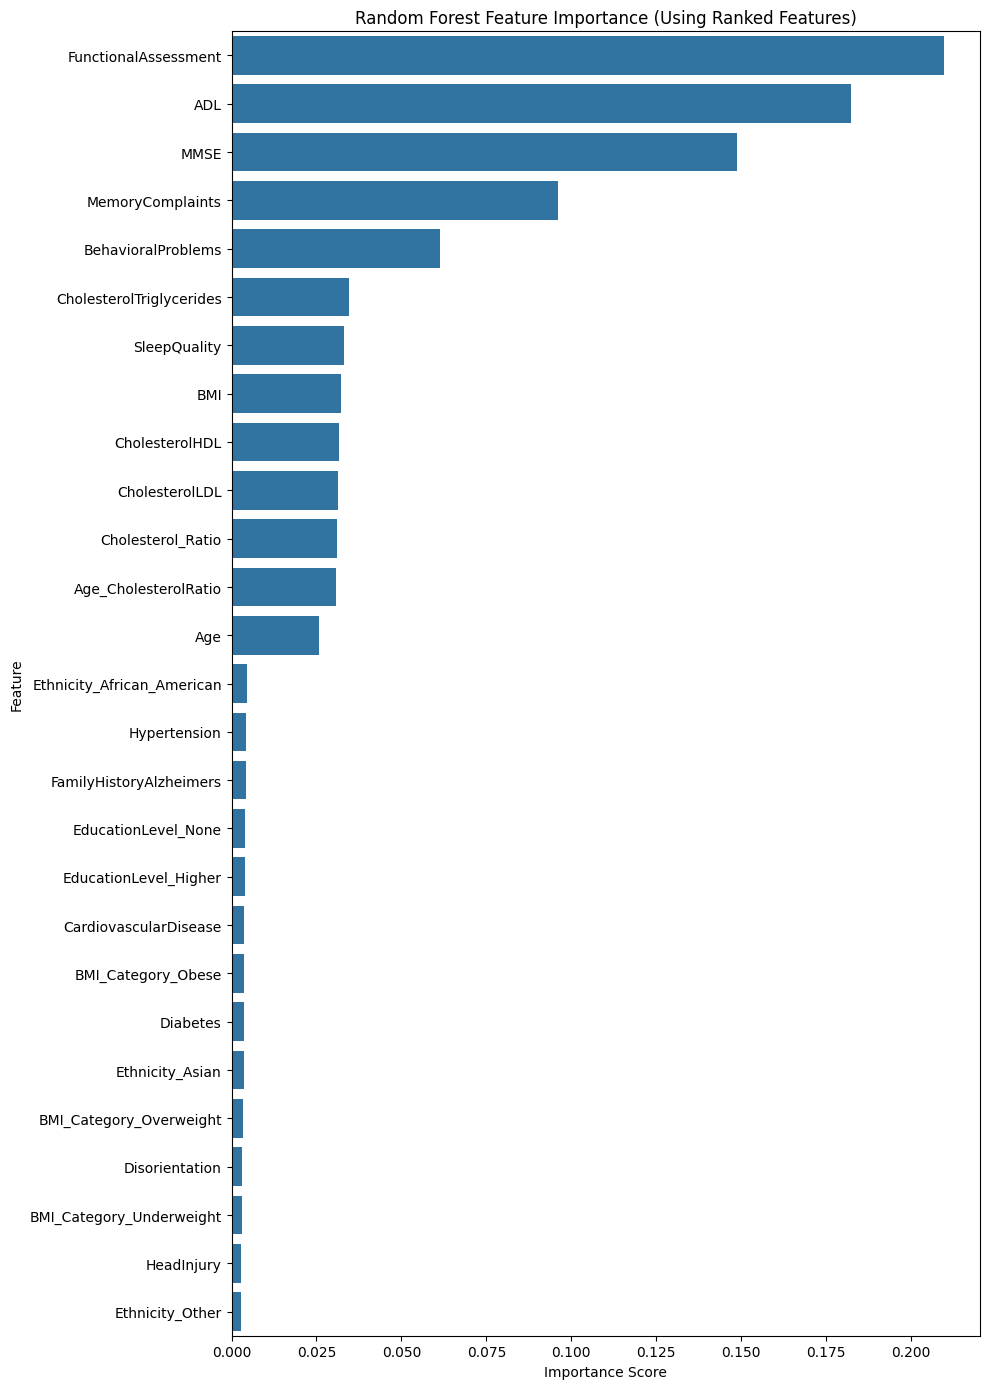

In [34]:
plt.figure(figsize=(10, 14))
sns.barplot(data=rf_selected_df, x='RF_Importance', y='Feature')
plt.title("Random Forest Feature Importance (Using Ranked Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [ ]:
FINAL_FEATURES = [
    'FunctionalAssessment',
    'ADL',
    'MMSE',
    'MemoryComplaints',
    'BehavioralProblems',
    'CholesterolTriglycerides',
    'SleepQuality',
    'BMI',
    'CholesterolHDL',
    'CholesterolLDL',
    'Age',
    'FamilyHistoryAlzheimers'
]
df1 = df[FINAL_FEATURES]
display(df1.head())

,FunctionalAssessment,ADL,MMSE,MemoryComplaints,BehavioralProblems,CholesterolTriglycerides,SleepQuality,BMI,CholesterolHDL,CholesterolLDL,Age,FamilyHistoryAlzheimers
0,6.518877,1.725883,21.463532,0,0,162.189143,9.025679,22.927749,33.682563,56.150897,73,0
1,7.118696,2.592424,20.613267,0,0,294.630909,7.151293,26.827681,79.028477,193.407996,89,0
2,5.895077,7.119548,7.356249,0,0,83.638324,9.673574,17.795882,69.772292,153.322762,73,1
3,8.965106,6.481226,13.991127,0,1,277.577358,8.392554,33.800817,68.457491,65.366637,74,0
4,6.045039,0.014691,13.517609,0,0,291.198780,5.597238,20.716974,56.874305,92.869700,89,0


In [42]:
X = df1
y = df['Diagnosis']

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (2149, 12)
Shape of y: (2149,)


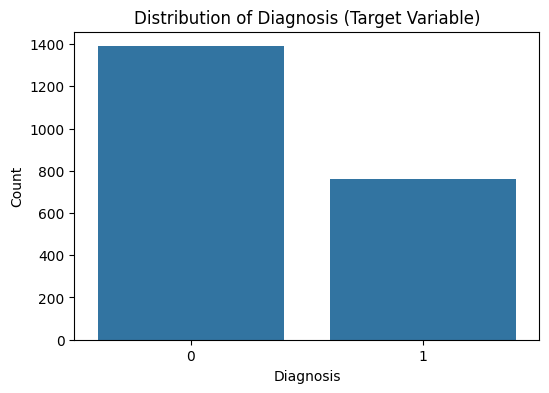

In [43]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Distribution of Diagnosis (Target Variable)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [39]:
print(y.value_counts())

Diagnosis
0    1389
1     760
Name: count, dtype: int64
